# 1D convolution problem - Gibbs MCMC vs INLA 

Recover 1D function from blurred, noisy data along with prior precision hyperparameter

Gaussian prior, gamma hyperpriors

Uses Gibbs sampler and also computes the distribution explicitly as in INLA, getting the same distribution

See "Efficient Marginalization-Based MCMC Methods for Hierarchical Bayesian Inverse Problems", Saibaba et al. 2019 and
"MCMC-Based Image Reconstruction with Uncertainty Quantification", Bardsley, 2012

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

In [2]:
# Define the true signal (1D image)
def true_signal(x):
    return 50*np.exp(-((x-0.75)/0.1)**2) + 37*np.logical_and(x>0.1,x<0.25) + 13*np.logical_and(x>0.3,x<0.32) 

# Generate observed blurred data
def generate_blurred_data(true_signal, x, A, lam):
    noise_std = 1/np.sqrt(lam)
    blurred_signal = np.dot(A,true_signal(x))
    noise = np.random.normal(0, noise_std, len(x))
    return blurred_signal + noise

# Define a Gaussian blur kernel
def gaussian_kernel(x, gamma):
    return np.exp(-x**2 / (2 * gamma**2))/np.sqrt(np.pi*gamma**2)

# Gibbs sampler
def gibbs(delta_initial, observed_data, A, L, N, lam, alpha_del, beta_del, n_iter=10):
    theta_samples = np.zeros((N,n_iter))
    delta_samples = np.zeros(n_iter+1)
    delta_samples[0] = delta_initial
    
    for idx in range(n_iter):
        K = np.linalg.cholesky(lam*np.dot(np.transpose(A),A) + delta_samples[idx]*L)
        w = np.dot(K,np.random.randn(N))
        y = solve_triangular(K,lam*np.dot(np.transpose(A),observed_data) + w, lower=True)
        theta_samples[:,idx] = solve_triangular(K,y,lower=True,trans='T')
        
        delta_shape = N/2 + alpha_del
        delta_rate = 0.5 * np.dot(theta_samples[:,idx],np.dot(L,theta_samples[:,idx])) + beta_del
        
        delta_samples[idx+1] = np.random.gamma(delta_shape, 1/delta_rate)
        
    return theta_samples, delta_samples


# Explicitly compute log p(gamma | data)
def logpi_gamma(gamma, lam, A, data):
    alpha_gam = alpha_del
    beta_gam = beta_del
    # compute prior precision L
    Lap = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
    L = gamma*Lap
    L = np.dot(L,L)
    
    # compute posterior precision and mean
    Lpost = lam*np.dot(np.transpose(A),A) + L
    xpost = lam*np.dot(np.transpose(A),data)
    xpost = np.linalg.solve(Lpost, xpost)
    
    # compute negative log of determinant ratio
    (sdetL, logdetL) = np.linalg.slogdet(L)
    (sdetLpost, logdetLpost) = np.linalg.slogdet(Lpost)
    det_ratio = - 0.5*logdetLpost + 0.5*logdetL + N/2*np.log(lam) + (alpha_gam-1)*np.log(gamma)
    
    # compute data, posterior mean, and hyperprior terms
    uQu_term = -0.5*(lam*np.dot(data,data) - np.dot(xpost, np.dot(Lpost, xpost))) 
    prior_term = - beta_gam*gamma
    
    return det_ratio+uQu_term+prior_term, det_ratio, prior_term, uQu_term
    

In [3]:
# Parameters and generating noisy blurred data

np.random.seed(42)
# discretization dimension
N = 80
x = np.linspace(0, 1, N)
# width of convolution stencil -- in this case the full interval
kernel_size = N
# stdev of gaussian convolution kernel
kernel_gamma = 0.03
# noise precision
lam = 5.35
# hyperprior parameters
alpha_del = 1
beta_del = 1e-4
# number of Gibbs iterations
iters = 1000

# blurring matrix
A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        d = min(np.abs(i-j),N-np.abs(i-j))
        A[i,j] = gaussian_kernel(d/N, kernel_gamma)/N
# fix scaling (since h=1/N isn't small enough for the kernel to integrate to ~1 numerically)
A = A/np.sum(A[0,:]) 

# Generate data
observed_data = generate_blurred_data(true_signal, x, A, lam)

# # Initial guess for the hyperparameters
delta_initial = 0.4

# Gibbs Sampling

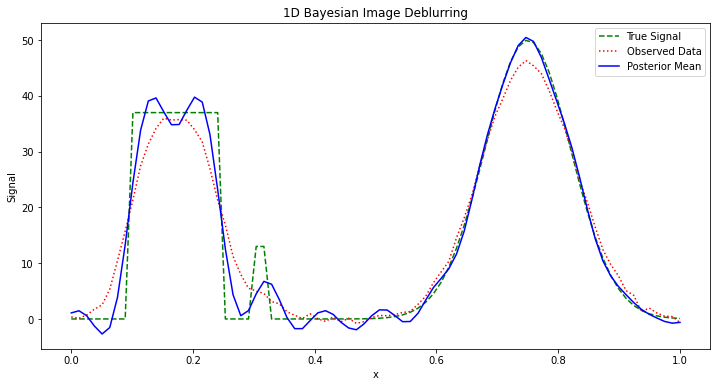

In [4]:
# Run Gibbs sampling

# Prior precision matrix
# Laplacian squared
L_gibbs = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
L_gibbs = np.dot(L_gibbs,L_gibbs)
# # (I + Laplacian)^2
# L = 3*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
# L = np.dot(L,L)

theta_samples, delta_samples = gibbs(delta_initial, observed_data, A, L_gibbs, N, lam, alpha_del, beta_del, n_iter=iters)

# Burn-in
start_idx = int(np.floor(iters/5))

# Compute the posterior mean
posterior_mean = np.mean(theta_samples[:,start_idx:iters-1], axis=1)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(x, true_signal(x), label="True Signal", linestyle='dashed', color='green')
plt.plot(x, observed_data, label="Observed Data", linestyle='dotted', color='red')
plt.plot(x, posterior_mean, label="Posterior Mean", color='blue')
plt.legend()
plt.title("1D Bayesian Image Deblurring")
plt.xlabel("x")
plt.ylabel("Signal")
plt.show()

Text(0.5, 1.0, 'Prior precision distribution')

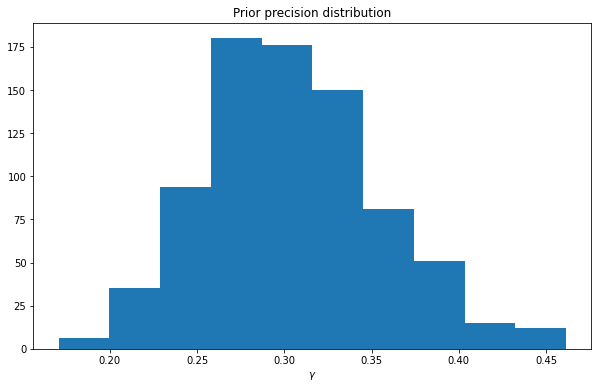

In [5]:
# with L = Laplacian^2, delta in the MCMC method corresponds to gamma^2 in (delta*I + gamma*Laplacian)^2, so 
# take a square root of delta to get something we can compare to gamma using the INLA method
delta_sqrts = np.sqrt(delta_samples[start_idx:iters])
plt.figure(figsize=(10, 6))
#plt.hist(delta_sqrts,bins=20)
plt.hist(delta_sqrts)
plt.xlabel(r'$\gamma$')
plt.title('Prior precision distribution')

# INLA

In [6]:
#del_range = np.linspace(0.0001, 0.0005, 30)
gam_range = np.linspace(0.0001, 0.6, 30)

# # compute - log pi(gamma, delta | data)
# neglogpi = np.zeros((len(gam_range),len(del_range)))
# for i in range(len(gam_range)):
#     for j in range(len(del_range)):
#         neglogpi_ij = -logpi_gamma_delta(gam_range[i],del_range[j], lam, A, observed_data)
#         neglogpi[i,j] = neglogpi_ij
        
# compute - log pi(gamma | data), for delta = 0
neglogpi = np.zeros(len(gam_range))
det_ratios = np.zeros(len(gam_range))
priors = np.zeros(len(gam_range))
uQus = np.zeros(len(gam_range))
for i in range(len(gam_range)):
    logpi_i,det_i,pri_i,uQu_i = logpi_gamma(gam_range[i], lam, A, observed_data)
    neglogpi[i] = -logpi_i
    det_ratios[i] = -det_i
    priors[i] = -pri_i
    uQus[i] = -uQu_i

In [7]:
# # plot -log pi(gamma, delta | data)
# plt.pcolormesh(del_range,gam_range,neglogpi)
# plt.colorbar()
# plt.title(r'$-log \, \pi(\gamma, \delta | data)$')
# plt.ylabel(r'$\gamma$')
# plt.xlabel(r'$\delta$')

Text(0, 0.5, '$-log \\pi(\\gamma | data)$')

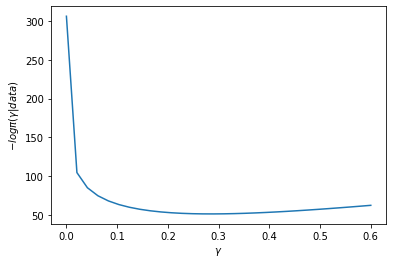

In [8]:
plt.plot(gam_range, neglogpi)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$-log \pi(\gamma | data)$')

Text(0.5, 1.0, '$\\pi(\\gamma | data)$')

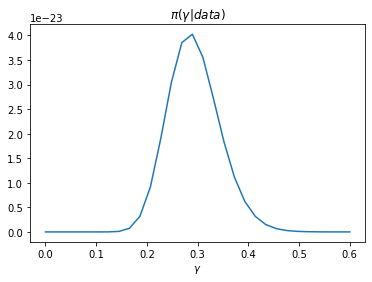

In [9]:
plt.plot(gam_range,np.exp(-neglogpi))
plt.xlabel(r'$\gamma$')
plt.title(r'$\pi(\gamma | data)$')